In [ ]:
import os
import sys

# Making the project root available to the notebook
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)

Project root: c:\Users\PC\Documents\personal-finance-multi-agent


# Personal Finance Assistant — Multi-Agent AI System

This notebook demonstrates a multi-agent Personal Finance Assistant.

The system uses specialized agents to:
- Categorize financial transactions
- Analyze the monthly budget
- Detect spending patterns
- Generate hypothetical savings scenarios
- Review the analysis using a risk and compliance critic

The workflow is coordinated by a supervisor using LangGraph and includes human approval and a revision loop.

In [2]:
from src.tools.transaction_reader import read_transactions

transactions_df = read_transactions(
    "../data/sample_transactions.csv"
)

transactions_df

,date,description,amount
0,2026-09-01,Salary,120000
1,2026-09-02,Apartment Rent,-30000
2,2026-09-03,Naivas Supermarket,-8500
3,2026-09-04,Uber,-1500
4,2026-09-05,Netflix,-1500
5,2026-09-06,Kenya Power,-4000
6,2026-09-08,Restaurant,-4500
7,2026-09-10,Clothing Store,-7000
8,2026-09-12,Uber,-1800
9,2026-09-15,Naivas Supermarket,-6000


In [3]:
from src.tools.calculator import (
    calculate_income,
    calculate_expenses,
    calculate_remaining,
)

transactions = transactions_df.to_dict("records")

income = calculate_income(transactions)
expenses = calculate_expenses(transactions)
remaining = calculate_remaining(income, expenses)

print("Income:", income)
print("Expenses:", expenses)
print("Remaining:", remaining)

Income: 120000
Expenses: 88900
Remaining: 31100


In [4]:
from src.tools.visualization import create_spending_chart

chart_path = create_spending_chart(
    transactions,
    "../screenshots/notebook_spending_by_category.png"
)

print("Chart created:", chart_path)

Chart created: ../screenshots/notebook_spending_by_category.png


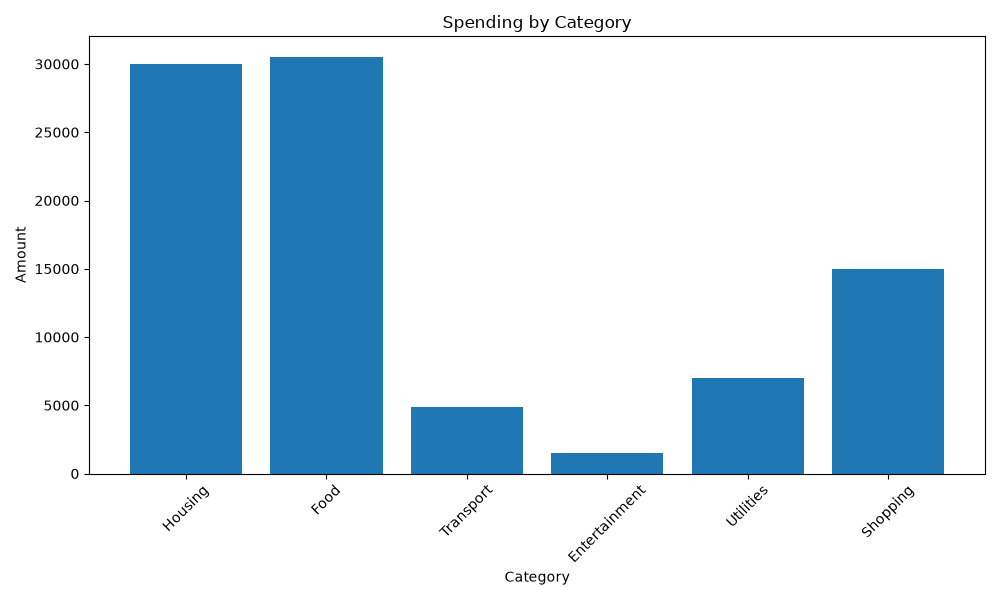

In [5]:
from IPython.display import Image, display

display(Image(filename="../screenshots/notebook_spending_by_category.png"))

## Multi-Agent Workflow

The supervisor coordinates five specialized agents:

1. Transaction Categorizer
2. Budget Analyst
3. Spending Pattern Detector
4. Savings Advisor
5. Risk and Compliance Critic

The workflow also includes human approval before the final critic review.

In [6]:
from src.supervisor import build_graph

graph = build_graph()

initial_state = {
    "user_query": (
        "Analyze my spending, create a budget, "
        "identify spending patterns, and create "
        "six-month savings scenarios."
    ),
    "transactions": transactions,
    "income": income,
    "expenses": expenses,
    "remaining": remaining,
    "revision_count": 0,
    "human_approved": None,
    "human_feedback": "",
}

final_result = initial_state.copy()

for update in graph.stream(initial_state):
    for node_name, state_update in update.items():
        print(f"[Completed: {node_name}]")

        if isinstance(state_update, dict):
            final_result.update(state_update)

[Completed: supervisor]
[Completed: categorizer]
[Completed: supervisor]
[Completed: budget]
[Completed: supervisor]
[Completed: patterns]
[Completed: supervisor]
[Completed: savings]
[Completed: supervisor]

HUMAN APPROVAL REQUIRED

The Savings Advisor proposed:
['Here are three hypothetical monthly savings scenarios based on your available monthly amount and spending observations:\n\n### 1. Conservative Savings Scenario\n- **Monthly Savings Amount:** 1,000\n- **Six-Month Total:** 6,000\n- **Assumptions:**\n  - You prioritize essential expenses and maintain a minimal savings goal.\n  - You continue to spend on necessary categories like housing, food, and utilities without significant changes.\n  - Discretionary spending (entertainment and shopping) remains at current levels, with no reductions.\n\n### 2. Moderate Savings Scenario\n- **Monthly Savings Amount:** 3,000\n- **Six-Month Total:** 18,000\n- **Assumptions:**\n  - You make some adjustments to discretionary spending, such as red

In [7]:
print("Income:", final_result.get("income"))
print("Expenses:", final_result.get("expenses"))
print("Remaining:", final_result.get("remaining"))

print("\nHuman approved:", final_result.get("human_approved"))
print("Critic approved:", final_result.get("approved"))
print("Critique:", final_result.get("critique"))

Income: 120000
Expenses: 88900
Remaining: 31100

Human approved: True
Critic approved: True
Critique: APPROVED

The analysis accurately reflects the authoritative financial values, with no numerical inconsistencies found. The observations regarding spending patterns are well-supported by the provided data, and the savings scenarios clearly outline their assumptions, making them hypothetical and not guaranteed outcomes. There are no invented transactions or unsupported claims, and the recommendations are reasonable without being overly certain. Overall, the analysis is thorough and aligns with the provided financial information.
